## Вычисляем  регрессию для признака CC50 используя  разные наборы  данных из исходного датасета, а так же пробуем  PCA, для основной модели использую  Gradient Boosting, так как она давала  чаще других стабильные результаты

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from skfeature.function.similarity_based import fisher_score

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.feature_selection import RFECV, SelectFromModel, mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [2]:
#Загружаем предобработанный датасет и  данные отобранные на  шаге исследования (EDA) различными методами
drugs_all = pd.read_csv('drugs_fin_clean.csv') #
select_sum = pd.read_csv('selected_sum.csv')
select_cP_tF = pd.read_csv('select_cP_tF.csv')
selected_features_MutRegr = pd.read_csv('selected_features_MutRegrv2.csv')
select_RF = pd.read_csv('select_RF.csv')
selected_features_Lasso = pd.read_csv('selected_features_Lasso.csv')
selected_features_Forward = pd.read_csv('selected_features_Forward.csv')
selected_features_Backwards = pd.read_csv('selected_features_Backwards.csv')

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:

feature_sets = {
    'MI': selected_features_MutRegr['0'].tolist(),
    'select_sum': select_sum['0'].tolist(),
    'select_cP_tF': select_cP_tF['0'].tolist(),
    'select_RF': select_RF['0'].tolist(),
    'selected_features_Backwards': selected_features_Backwards['0'].tolist()
}


Train: (775, 211), Test: (194, 211)

=== Сравнение методов отбора ===
                Feature Set  n_features        CV R^2 Test R^2 Test MAE Test RMSE
                         MI          53 0.452 ± 0.044    0.292    0.881     1.332
                 select_sum         134 0.468 ± 0.055    0.250    0.908     1.370
               select_cP_tF         120 0.447 ± 0.045    0.249    0.914     1.371
                  select_RF         100 0.465 ± 0.057    0.247    0.912     1.373
selected_features_Backwards          80 0.457 ± 0.052    0.262    0.901     1.359
        PCA (60 components)          60 0.378 ± 0.103    0.410    0.875     1.215

 Финальная модель
Лучший набор признаков: PCA (60 components)

Финальные метрики на тесте:
  R^2 = 0.3941
  MAE = 0.8413
  RMSE = 1.2315


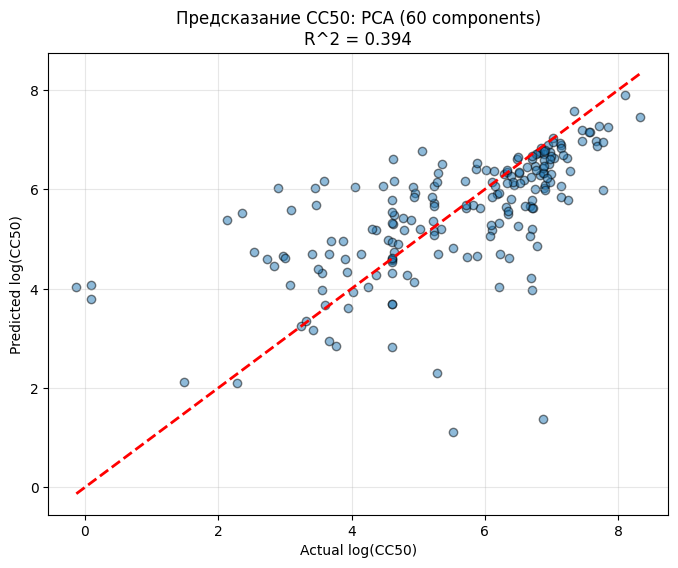

In [25]:

X = drugs_all.drop(columns=['SI','CC50, mM']).copy()
y = drugs_all['CC50, mM'].values

feature_names = X.columns.tolist()

# Разделение данных

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Дополнительно: PCA baseline
pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

results = []

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

for name, feat_list in feature_sets.items():
    if len(feat_list) == 0:
        continue
    
    # Подмножество признаков
    if isinstance(feat_list, list) and len(feat_list) > 0:
        #idx = [feature_names.index(f) for f in feat_list if f in feature_names]
        # Или если нужно проверить наличие признаков
        existing_features = [f for f in feat_list if f in X_train_df.columns]
        X_train_sub = X_train_df[existing_features].values
        X_test_sub = X_test_df[existing_features].values
        #X_train_sub = X_train_scaled[:, idx]
        #X_test_sub = X_test_scaled[:, idx]
    else:
        continue
    
    # Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
    rf_model.fit(X_train_sub, y_train)
    y_pred = rf_model.predict(X_test_sub)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Кросс-валидация
    cv_scores = cross_val_score(rf_model, X_train_sub, y_train, cv=5, scoring='r2')
    
    results.append({
        'Feature Set': name,
        'n_features': len(feat_list),
        'CV R^2': f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
        'Test R^2': f"{r2:.3f}",
        'Test MAE': f"{mae:.3f}",
        'Test RMSE': f"{rmse:.3f}"
    })

# Добавляем PCA
rf_pca = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)
cv_scores_pca = cross_val_score(rf_pca, X_train_pca, y_train, cv=5, scoring='r2')

results.append({
    'Feature Set': 'PCA (60 components)',
    'n_features': 60,
    'CV R^2': f"{cv_scores_pca.mean():.3f} ± {cv_scores_pca.std():.3f}",
    'Test R^2': f"{r2_score(y_test, y_pred_pca):.3f}",
    'Test MAE': f"{mean_absolute_error(y_test, y_pred_pca):.3f}",
    'Test RMSE': f"{np.sqrt(mean_squared_error(y_test, y_pred_pca)):.3f}"
})

results_df = pd.DataFrame(results)
print("\n=== Сравнение методов отбора ===")
print(results_df.to_string(index=False))


# Финальная модель с лучшим набором признаков

print("\n Финальная модель")

# Выбираем лучший набор (по Test R^2)
best_row = results_df.loc[results_df['Test R^2'].astype(float).idxmax()]
best_set_name = best_row['Feature Set']
print(f"Лучший набор признаков: {best_set_name}")

if best_set_name == 'PCA (60 components)':
    X_train_final = X_train_pca
    X_test_final = X_test_pca
    final_features = [f'PC{i+1}' for i in range(30)]
else:
    best_features = feature_sets[best_set_name]
    feature_index = pd.Index(feature_names)
    idx = feature_index.get_indexer(best_features)
    # Фильтруем -1 (ненайденные признаки)
    idx = idx[idx >= 0]
    
    # Проверяем потери
    found_features = [best_features[i] for i in range(len(best_features)) if idx[i] >= 0]
    missing_features = set(best_features) - set(found_features)
    
    if missing_features:
        print(f"Не найдены признаки: {list(missing_features)[:5]}")
    
    X_train_final = X_train_scaled[:, idx]
    X_test_final = X_test_scaled[:, idx]
    final_features = best_features


# Финальная модель 
final_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)
final_model.fit(X_train_final, y_train)
y_pred_final = final_model.predict(X_test_final)

print(f"\nФинальные метрики на тесте:")
print(f"  R^2 = {r2_score(y_test, y_pred_final):.4f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")

# Визуализация предсказаний
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel(f'Actual log(CC50)')
plt.ylabel('Predicted log(CC50)')
plt.title(f'Предсказание CC50: {best_set_name}\nR^2 = {r2_score(y_test, y_pred_final):.3f}')
plt.grid(True, alpha=0.3)
plt.show()



In [ ]:
# ============Опциональный блок======
# Сохранение результатов

# Сохраняем список отобранных признаков
#pd.Series(final_features).to_csv('selected_features_for_СС50.csv', index=False)
#
## Сохраняем результаты всех методов
#vote_df.to_csv('feature_voting_results.csv', index=False)
#results_df.to_csv('feature_selection_comparison.csv', index=False)
#
## Сохраняем финальную модель
#import joblib
#joblib.dump(final_model, 'сс50_prediction_model.pkl')
#joblib.dump(scaler, 'scaler.pkl') #чтобы при предсказании применять ту же нормализацию входных данных

#print("\n=== Сохраненные файлы ===")
#print("  - selected_features_for_СС50.csv — отобранные признаки")
#print("  - feature_voting_results.csv — перебор методов")
#print("  - feature_selection_comparison.csv — сравнение качества")
#print("  - si_prediction_model.pkl — финальная модель")

## Попробуем улучшить результат на  финальных данных после PCA (X_train_final),  возьмем модель RF  и  подберем гипер параметры 

In [ ]:
# параметры для Grid Search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Инициализация Random Forest
rf = RandomForestRegressor()

# Настройка Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           scoring='neg_mean_squared_error', n_jobs=-1, cv=5, verbose=2)

# Обучение модели
grid_search.fit(X_train_final, y_train)

# Лучшие параметры
best_params2 = grid_search.best_params_
print(f"Лучшие параметры: {best_params2}")

# Используем наилучшие параметры для финальной модели
best_rf = grid_search.best_estimator_

# Предсказания на тестовой выборке
y_pred_best = best_rf.predict(X_test_final)

# Оценка модели
mse = mean_squared_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)
print(f"Средняя квадратичная ошибка (MSE): {mse:.4f}")
print(f"Коэффициент детерминации R^2: {r2:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5